# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [2]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [3]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# First removing the path by split and then splitting the string to get the label
# input_path = [i for i in glob('Dataset\*\*\*.mp4')]
input_path = [i for i in glob('MP_Data\*\*.npy') if 'centered' not in i]
output_label = [i.split("\\")[-1] for i in glob('MP_data\*')] 

print(output_label)
input_path[:5]

['Beautiful', 'Blind', 'Deaf', 'happy', 'loud', 'quiet', 'sad', 'Ugly']


['MP_Data\\Beautiful\\MVI_9569.npy',
 'MP_Data\\Beautiful\\MVI_9569_downsampled.npy',
 'MP_Data\\Beautiful\\MVI_9569_flipped.npy',
 'MP_Data\\Beautiful\\MVI_9569_upsampled.npy',
 'MP_Data\\Beautiful\\MVI_9570.npy']

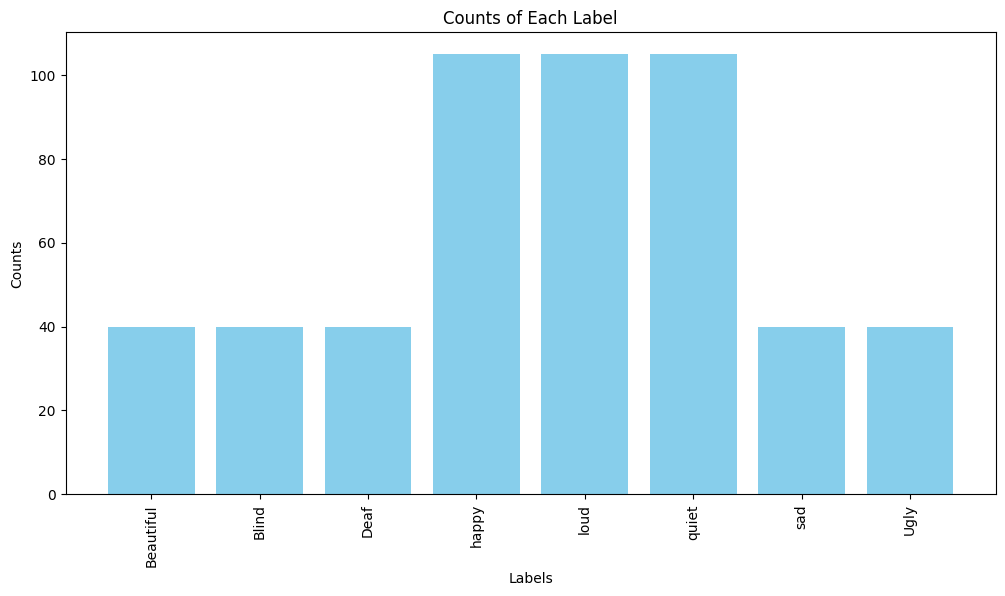

In [6]:
import matplotlib.pyplot as plt

# Count the occurrences of each label in y
label_counts = [len(os.listdir(i)) for i in glob('MP_data\*')]

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(output_label, label_counts, color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Counts of Each Label')
plt.xticks(rotation=90)
plt.show()

In [7]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),len(labels)

(37     MP_Data\Blind\MVI_9585_downsampled.npy
 389     MP_Data\Ugly\MVI_9578_downsampled.npy
 157    MP_Data\happy\MVI_9454_downsampled.npy
 304                MP_Data\quiet\MVI_9293.npy
 54         MP_Data\Blind\MVI_9853_flipped.npy
 dtype: object,
 8)

In [8]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'Beautiful',
 1: 'Blind',
 2: 'Deaf',
 3: 'happy',
 4: 'loud',
 5: 'quiet',
 6: 'sad',
 7: 'Ugly'}

In [9]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    
    
    for video in label_videos[:40]:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        
        # Prinintg npy file containing face mesh
        if len(res[0]) == 1662:
            print(video)
        
        X.append(res)
        y.append(labels.index(label))      

len(X),len(y)

  0%|          | 0/8 [00:00<?, ?it/s]

(320, 320)

In [11]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
print(f"Max frames: {max_frames}")

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)

Max frames: 79
(320, 79, 258)


In [12]:
X= np.array(X)
y= np.array(y)
# X= tf.convert_to_tensor(X)
# y= tf.convert_to_tensor(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (256, 79, 258)
X_val shape: (64, 79, 258)
y_train shape: (256, 8)
y_val shape: (64, 8)


# Model

## Architecture

In [13]:
import keras

# input_shape = (79, 1662)
input_shape = X_train[0].shape #(79, 1662)
num_classes =  len(label_map.keys())#50
input_shape,num_classes

((79, 258), 8)

In [59]:


INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_6 (Bidirectio  (None, 79, 128)          165376    
 nal)                                                            
                                                                 
 bidirectional_7 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 bidirectional_8 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 bidirectional_9 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 flatten_9 (Flatten)         (None, 10112)            

In [32]:
INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        # Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 79, 128)          165376    
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 79, 256)          263168    
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 79, 128)          164352    
 nal)                                                            
                                                                 
 flatten_5 (Flatten)         (None, 10112)             0         
                                                                 
 dense_14 (Dense)            (None, 64)                647232    
                                                      

In [14]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GRU


INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        GRU(64, return_sequences=True),
        GRU(128, return_sequences=True),
        GRU(64, return_sequences=True),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V4

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 79, 64)            62208     
                                                                 
 gru_1 (GRU)                 (None, 79, 128)           74496     
                                                                 
 gru_2 (GRU)                 (None, 79, 64)            37248     
                                                                 
 flatten (Flatten)           (None, 5056)              0         
                                                                 
 dense (Dense)               (None, 64)                323648    
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 8)                 2

In [54]:
INCLUDE8_V5 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        LSTM(64, return_sequences=True),
        LSTM(128, return_sequences=True),
        LSTM(128, return_sequences=True),
        LSTM(64, return_sequences=True),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V5

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_9 (LSTM)               (None, 79, 64)            82688     
                                                                 
 lstm_10 (LSTM)              (None, 79, 128)           98816     
                                                                 
 lstm_11 (LSTM)              (None, 79, 128)           131584    
                                                                 
 lstm_12 (LSTM)              (None, 79, 64)            49408     
                                                                 
 flatten_8 (Flatten)         (None, 5056)              0         
                                                                 
 dense_23 (Dense)            (None, 64)                323648    
                                                                 
 dense_24 (Dense)            (None, 32)               

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=50
          ,callbacks=[early_stop])

Epoch 1/50
8/8 [==============================] - 6s 148ms/step - loss: 2.1055 - accuracy: 0.1406 - val_loss: 2.0018 - val_accuracy: 0.1719
Epoch 2/50
8/8 [==============================] - 0s 32ms/step - loss: 1.9885 - accuracy: 0.1875 - val_loss: 1.8732 - val_accuracy: 0.2656
Epoch 3/50
8/8 [==============================] - 0s 31ms/step - loss: 1.7620 - accuracy: 0.3086 - val_loss: 1.8059 - val_accuracy: 0.2500
Epoch 4/50
8/8 [==============================] - 0s 29ms/step - loss: 1.4763 - accuracy: 0.4531 - val_loss: 1.2875 - val_accuracy: 0.5156
Epoch 5/50
8/8 [==============================] - 0s 28ms/step - loss: 1.2226 - accuracy: 0.5273 - val_loss: 1.2080 - val_accuracy: 0.4688
Epoch 6/50
8/8 [==============================] - 0s 29ms/step - loss: 1.0048 - accuracy: 0.6133 - val_loss: 1.0284 - val_accuracy: 0.5156
Epoch 7/50
8/8 [==============================] - 0s 30ms/step - loss: 0.8316 - accuracy: 0.6445 - val_loss: 1.0838 - val_accuracy: 0.5469
Epoch 8/50
8/8 [==========

## Model Reuslts

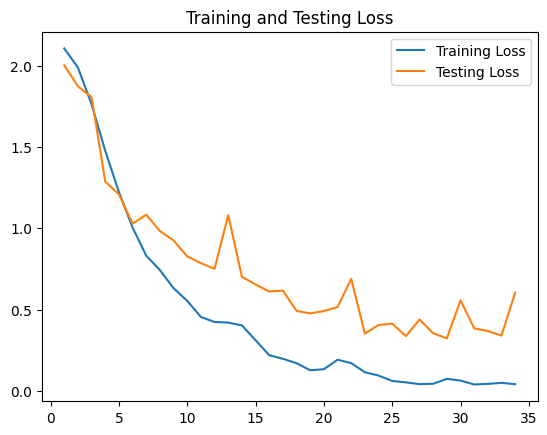

<Figure size 640x480 with 0 Axes>

In [16]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

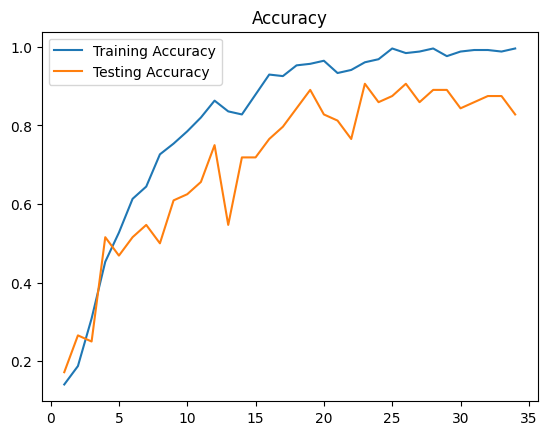

<Figure size 640x480 with 0 Axes>

In [17]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

2/2 [==============================] - 1s 19ms/step


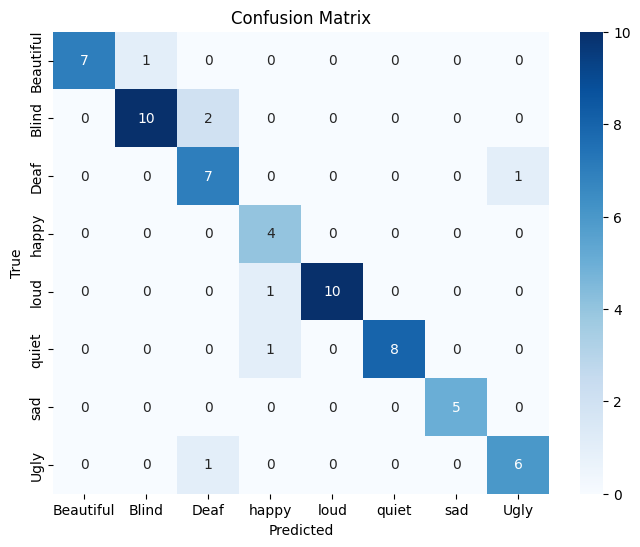

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert one-hot encoded y_val to class labels
true_classes = np.argmax(y_val, axis=-1)

probabilities = model.predict(X_val)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

In [20]:
# Accuracy
total = len(X_val)
pred = 0
for i in range(total):
   if (label_map[predicted_classes[i]]) == (label_map[np.argmax(y_val[i])]):
         pred += 1

acc = (pred/total)*100

f"Acc, Total, Pred: {acc}, {total}, {pred}"

'Acc, Total, Pred: 89.0625, 64, 57'

### Saving Model

In [21]:
try:
    os.mkdir("Model")
except:
    pass

model.save("Model\INCLUDE_8_V4_noFlip.h5")